## Neural Network Model #1: **Multi-Layer Perceptron**

First, we will import our pre-split and scaled training, validation, and test sets.

In [46]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import numpy as np

# Load the preprocessed and scaled data
X_train_scaled = joblib.load('processed_data/X_train_scaled.pkl')
X_val_scaled = joblib.load('processed_data/X_val_scaled.pkl')
X_test_scaled = joblib.load('processed_data/X_test_scaled.pkl')

y_train = joblib.load('processed_data/y_train.pkl')
y_val = joblib.load('processed_data/y_val.pkl')
y_test = joblib.load('processed_data/y_test.pkl')

In [49]:
from MCO_functions import trainNetwork, evaluateNetwork
from data_loader import DataLoader
from neural_network import NeuralNetwork
import torch.optim as optim
import torch.nn as nn
import numpy as np

# Ensure deterministic behavior for reproducibility
import torch, numpy as np, random, os

# load data into PyTorch tensors
nn_X_train = torch.from_numpy(X_train_scaled.to_numpy()).float()
nn_y_train = torch.from_numpy(y_train.to_numpy()).long()

nn_X_val = torch.from_numpy(X_val_scaled.to_numpy()).float()
nn_y_val = torch.from_numpy(y_val.to_numpy()).long()

nn_X_test = torch.from_numpy(X_test_scaled.to_numpy()).float()
nn_y_test = torch.from_numpy(y_test.to_numpy()).long()

# **[4]** Model Selection Training


In predicting urban and rural households, we employ a multi-layer perceptron, as these are known to be effective at handling non-linear problems and large datasets.

https://www.datacamp.com/tutorial/multilayer-perceptrons-in-machine-learning  
https://h2o.ai/wiki/multilayer-perceptron/  

To get more effective final model, we accomplish the following:

1. Preliminary comparison of different neural network architectures
2. Comparison of hyperparameter configurations of the selected architecture(s)
3. Error analysis of the selected model and tuning

### Preliminary Comparison of different Neural Network Architectures

Rectified Linear Units (ReLu) is used as the activation function in training the neural networks for its less expensive computation compared to sigmoid.  

$$
ReLU(x)=max(0,x)
$$

$$
f(x)=
\begin{cases}
0 & \text{if } x < 0 \\
1 & \text{if } x \geq 0 
\end{cases}
$$  

We perform an initial grid search over different possible neural network architectures and compare their performance metrics in order to get a better configuration for the final model. These architectures follow the pyramid pattern, where after the first hidden layer, each layer has half the neurons of the previous. This approach is known to be more effective for tabular data.  

https://machinelearningtheory.org/docs/Deep-Learning/designing-the-architecture/  

An initial learning rate of 0.005 and a relatively smaller epoch limit of 15 is used to speed up the preliminary search. Each network architecture is trained and evaluated using multiple seeds, with each of their resulting metrics averaged to provide more stable performance estimates.

In [4]:
learning_rate = 0.005
# a relatively small epoch limit to prevent long training times during preliminary search
epoch_limit = 15

seeds = [0, 42, 123, 456, 789]  # different for multiple runs

# Define different architectures to test (number of hidden layers and their sizes)
configs = [
    (64, 32),
    (128, 64),
    (256, 128),
    (128, 64, 32),
    (256, 128, 64)
]

# list to store loss after each training epoch
loss_history = []

# to store results for each architecture
results = []

# Train and evaluate the neural network for each architecture configuration
criterion = nn.CrossEntropyLoss()
data_loader = DataLoader(nn_X_train, nn_y_train, batch_size=64)

for hidden_layers in configs:

    run_metrics = []  # to store metrics for this architecture

    for seed in seeds:
        # Set seeds for reproducibility
        os.environ['PYTHONHASHSEED'] = str(seed)
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.use_deterministic_algorithms(True)

        network = NeuralNetwork(
            input_size=88,
            list_hidden=hidden_layers,
            activation='relu',
            num_classes=2
        )

        print(f"\nTraining Neural Network with hidden layers: {hidden_layers}, seed: {seed}")

        network.create_network()

        optimizer = optim.Adam(network.parameters(), lr=learning_rate)

        training_losses = trainNetwork(network, data_loader, optimizer, criterion, max_epochs=epoch_limit)

        loss_history.append({
            "architecture": hidden_layers,
            "seed": seed,
            "losses": training_losses
        })

        # evaluate on both train and validation sets
        trainMetrics = evaluateNetwork(network, nn_X_train, nn_y_train)
        evalMetrics = evaluateNetwork(network, nn_X_val, nn_y_val)

        # store metrics of this run
        run_metrics.append({
            "train": trainMetrics,
            "val": evalMetrics
        })

    # compute averages across runs
    avg_train_metrics = {}
    for k, v in run_metrics[0]["train"].items():
        if isinstance(v, dict):  # nested dict
            for subk in v:
                avg_train_metrics[f"{k}_{subk}"] = np.mean([r["train"][k][subk] for r in run_metrics])
        else:  # simple float
            avg_train_metrics[k] = np.mean([r["train"][k] for r in run_metrics])
    
    avg_val_metrics = {}
    for k, v in run_metrics[0]["val"].items():
        if isinstance(v, dict):
            for subk in v:
                avg_val_metrics[f"{k}_{subk}"] = np.mean([r["val"][k][subk] for r in run_metrics])
        else:
            avg_val_metrics[k] = np.mean([r["val"][k] for r in run_metrics])

    # append averaged results for this architecture
    results.append({
        "architecture": hidden_layers,
        **{"train_" + k: v for k, v in avg_train_metrics.items()},
        **{"val_" + k: v for k, v in avg_val_metrics.items()}
    })


Training Neural Network with hidden layers: (64, 32), seed: 0
Epoch: 1 	Loss: 0.418677
Epoch: 2 	Loss: 0.388747
Epoch: 3 	Loss: 0.378329
Epoch: 4 	Loss: 0.369085
Epoch: 5 	Loss: 0.360969
Epoch: 6 	Loss: 0.352339
Epoch: 7 	Loss: 0.343843
Epoch: 8 	Loss: 0.335083
Epoch: 9 	Loss: 0.328521
Epoch: 10 	Loss: 0.321874
Epoch: 11 	Loss: 0.313931
Epoch: 12 	Loss: 0.307235
Epoch: 13 	Loss: 0.300827
Epoch: 14 	Loss: 0.295319
Epoch: 15 	Loss: 0.291942

Training Neural Network with hidden layers: (64, 32), seed: 42
Epoch: 1 	Loss: 0.416517
Epoch: 2 	Loss: 0.389038
Epoch: 3 	Loss: 0.378043
Epoch: 4 	Loss: 0.368627
Epoch: 5 	Loss: 0.360424
Epoch: 6 	Loss: 0.351023
Epoch: 7 	Loss: 0.343594
Epoch: 8 	Loss: 0.335654
Epoch: 9 	Loss: 0.329300
Epoch: 10 	Loss: 0.320523
Epoch: 11 	Loss: 0.314789
Epoch: 12 	Loss: 0.309178
Epoch: 13 	Loss: 0.304158
Epoch: 14 	Loss: 0.296448
Epoch: 15 	Loss: 0.288720

Training Neural Network with hidden layers: (64, 32), seed: 123
Epoch: 1 	Loss: 0.420369
Epoch: 2 	Loss: 0.388

Each architecture's change in loss throughout training is visualized using a line graph.

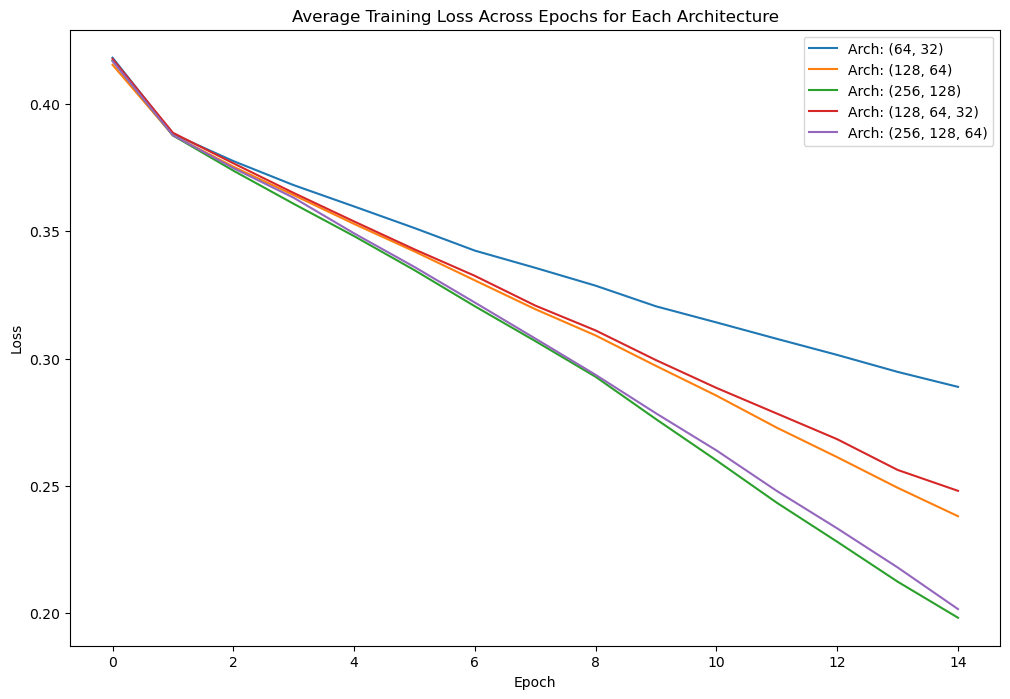

In [5]:
# graph loss history for each architecture (averaged across seeds)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for config in configs:
    # filter loss history for this architecture
    config_history = [h for h in loss_history if h["architecture"] == config]

    min_len = min(len(h["losses"]) for h in config_history)

    aligned_losses = [
        h["losses"][:min_len] for h in config_history
    ]
    
    # average losses across seeds
    avg_losses = np.mean(aligned_losses, axis=0)
    
    plt.plot(avg_losses, label=f"Arch: {config}")

plt.title("Average Training Loss Across Epochs for Each Architecture")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# **[5]** Error Analysis and Model Tuning

For each class, precision, recall, and f1-scores are used as metrics along with **balanced accuracy** instead of classic accuracy. Balanced accuracy, which is the average of the recall on each class, is more effective for classification problems on imbalanced sets. Between the **urban (class 1)** and **rural (class 0)** classes in the dataset, rural is the majority class. For the duration of the development of the multi-layer perceptron, any mention of the term accuracy will refer to balanced accuracy.  

$$\text{Balanced Accuracy} = \frac{1}{k} \sum_{i=1}^{k} \text{Recall}_i$$

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html

In [ ]:
results_flat = []
for r in results:
    flat_r = {
        "architecture": r["architecture"],
        "train_accuracy": r["train_accuracy"],
        "train_precision_rural": r["train_precision_class 0"],
        "train_precision_urban": r["train_precision_class 1"],
        "train_recall_rural": r["train_recall_class 0"],
        "train_recall_urban": r["train_recall_class 1"],
        "train_f1_rural": r["train_f1_class 0"],
        "train_f1_urban": r["train_f1_class 1"],
        "val_accuracy": r["val_accuracy"],
        "val_precision_rural": r["val_precision_class 0"],
        "val_precision_urban": r["val_precision_class 1"],
        "val_recall_rural": r["val_recall_class 0"],
        "val_recall_urban": r["val_recall_class 1"],
        "val_f1_rural": r["val_f1_class 0"],
        "val_f1_urban": r["val_f1_class 1"]
    }
    results_flat.append(flat_r)

results_df = pd.DataFrame(results_flat)
results_df.T

,0,1,2,3,4
architecture,"(64, 32)","(128, 64)","(256, 128)","(128, 64, 32)","(256, 128, 64)"
train_accuracy,0.86408,0.895966,0.921294,0.889979,0.918076
train_precision_rural,0.885489,0.917356,0.941205,0.909821,0.934733
train_precision_urban,0.863025,0.880559,0.900273,0.880922,0.907336
train_recall_rural,0.920336,0.926939,0.937412,0.928494,0.942908
train_recall_urban,0.807825,0.864994,0.905176,0.851464,0.893244
train_f1_rural,0.90252,0.922022,0.93918,0.919026,0.938632
train_f1_urban,0.834349,0.872453,0.902397,0.865843,0.899787
val_accuracy,0.799652,0.798537,0.79443,0.80138,0.794608
val_precision_rural,0.840219,0.845448,0.845774,0.843233,0.841242


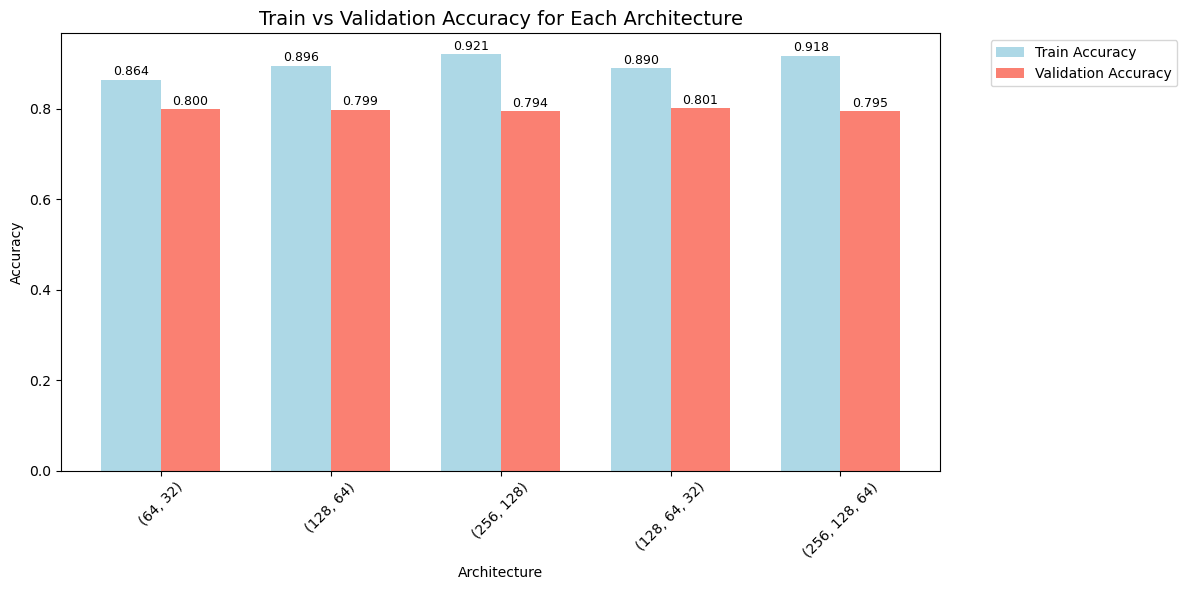

In [ ]:
# see distribution of balanced accuracy scores in the training and validation set across different architectures
plt.figure(figsize=(12, 6))
x = np.arange(len(results_df["architecture"]))
bar_width = 0.35
plt.bar(x - bar_width/2, results_df["train_accuracy"], width=bar_width, label='Train Accuracy', color='lightblue')
plt.bar(x + bar_width/2, results_df["val_accuracy"], width=bar_width, label='Validation Accuracy', color='salmon')
plt.title("Train vs Validation Accuracy for Each Architecture", fontsize=14)
plt.xlabel("Architecture")
plt.ylabel("Accuracy")
# position legend outside the plot area to avoid overlap
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(x, results_df["architecture"], rotation=45)
plt.tight_layout()

# allow user to see the values on top of the bars
for i in range(len(results_df)):
    plt.text(i - bar_width/2, results_df["train_accuracy"].iloc[i] + 0.01, f"{results_df['train_accuracy'].iloc[i]:.3f}", ha='center', fontsize=9)
    plt.text(i + bar_width/2, results_df["val_accuracy"].iloc[i] + 0.01, f"{results_df['val_accuracy'].iloc[i]:.3f}", ha='center', fontsize=9)

plt.show()

All architectures in the preliminary test had a similar validation balanced accuracy of approximately 0.8. Balanced accuracy is used as the primary metric for comparison because it gives equal weight to both the urban and rural classes. Given that the difference between the train and test balanced accuracy is greater than 5 percent, all architectures tested are likely overfitting on the training data. Thus, simpler architectures with better potential for generalization should be compared.  

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html  
https://iterate.ai/ai-glossary/balanced-accuracy  

In [19]:
learning_rate = 0.005
# the relatively small epoch limit is now a safeguard to prevent overfitting
epoch_limit = 15

seeds = [0, 42, 123, 456, 789]  # different for multiple runs

# Define different architectures to test (number of hidden layers and their sizes)
configs = [
    (32, 16),
    (16, 8),
    (8,4),
    (4,2)
]

# list to store loss after each training epoch
loss_history = []

# to store results for each architecture
results = []

# Train and evaluate the neural network for each architecture configuration
criterion = nn.CrossEntropyLoss()
data_loader = DataLoader(nn_X_train, nn_y_train, batch_size=64)

for hidden_layers in configs:

    run_metrics = []  # to store metrics for this architecture

    for seed in seeds:
        # Set seeds for reproducibility
        os.environ['PYTHONHASHSEED'] = str(seed)
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.use_deterministic_algorithms(True)

        network = NeuralNetwork(
            input_size=88,
            list_hidden=hidden_layers,
            activation='relu',
            num_classes=2
        )

        print(f"\nTraining Neural Network with hidden layers: {hidden_layers}, seed: {seed}")

        network.create_network()

        optimizer = optim.Adam(network.parameters(), lr=learning_rate)

        training_losses = trainNetwork(network, data_loader, optimizer, criterion, max_epochs=epoch_limit)

        loss_history.append({
            "architecture": hidden_layers,
            "seed": seed,
            "losses": training_losses
        })

        # evaluate on both train and validation sets
        trainMetrics = evaluateNetwork(network, nn_X_train, nn_y_train)
        evalMetrics = evaluateNetwork(network, nn_X_val, nn_y_val)

        # store metrics of this run
        run_metrics.append({
            "train": trainMetrics,
            "val": evalMetrics
        })

    # compute averages across runs
    avg_train_metrics = {}
    for k, v in run_metrics[0]["train"].items():
        if isinstance(v, dict):  # nested dict
            for subk in v:
                avg_train_metrics[f"{k}_{subk}"] = np.mean([r["train"][k][subk] for r in run_metrics])
        else:  # simple float
            avg_train_metrics[k] = np.mean([r["train"][k] for r in run_metrics])
    
    avg_val_metrics = {}
    for k, v in run_metrics[0]["val"].items():
        if isinstance(v, dict):
            for subk in v:
                avg_val_metrics[f"{k}_{subk}"] = np.mean([r["val"][k][subk] for r in run_metrics])
        else:
            avg_val_metrics[k] = np.mean([r["val"][k] for r in run_metrics])

    # append averaged results for this architecture
    results.append({
        "architecture": hidden_layers,
        **{"train_" + k: v for k, v in avg_train_metrics.items()},
        **{"val_" + k: v for k, v in avg_val_metrics.items()}
    })


Training Neural Network with hidden layers: (32, 16), seed: 0
Epoch: 1 	Loss: 0.425676
Epoch: 2 	Loss: 0.391691
Epoch: 3 	Loss: 0.383662
Epoch: 4 	Loss: 0.376447
Epoch: 5 	Loss: 0.371176
Epoch: 6 	Loss: 0.364428
Epoch: 7 	Loss: 0.359522
Epoch: 8 	Loss: 0.352965
Epoch: 9 	Loss: 0.348355
Epoch: 10 	Loss: 0.345691
Epoch: 11 	Loss: 0.339293
Epoch: 12 	Loss: 0.336860
Epoch: 13 	Loss: 0.332778
Epoch: 14 	Loss: 0.328968
Epoch: 15 	Loss: 0.325666

Training Neural Network with hidden layers: (32, 16), seed: 42
Epoch: 1 	Loss: 0.423526
Epoch: 2 	Loss: 0.390814
Epoch: 3 	Loss: 0.381427
Epoch: 4 	Loss: 0.374252
Epoch: 5 	Loss: 0.368292
Epoch: 6 	Loss: 0.361879
Epoch: 7 	Loss: 0.356942
Epoch: 8 	Loss: 0.350553
Epoch: 9 	Loss: 0.347677
Epoch: 10 	Loss: 0.342773
Epoch: 11 	Loss: 0.338109
Epoch: 12 	Loss: 0.334996
Epoch: 13 	Loss: 0.331071
Epoch: 14 	Loss: 0.327856
Epoch: 15 	Loss: 0.324505

Training Neural Network with hidden layers: (32, 16), seed: 123
Epoch: 1 	Loss: 0.422074
Epoch: 2 	Loss: 0.390

Training loss across epochs for each architecture is visualized in a line graph. The architecture (32,16) has a faster drop in loss than (16,8). Both have noticeably less drop in training loss across epochs compared to the previously evaluated models.

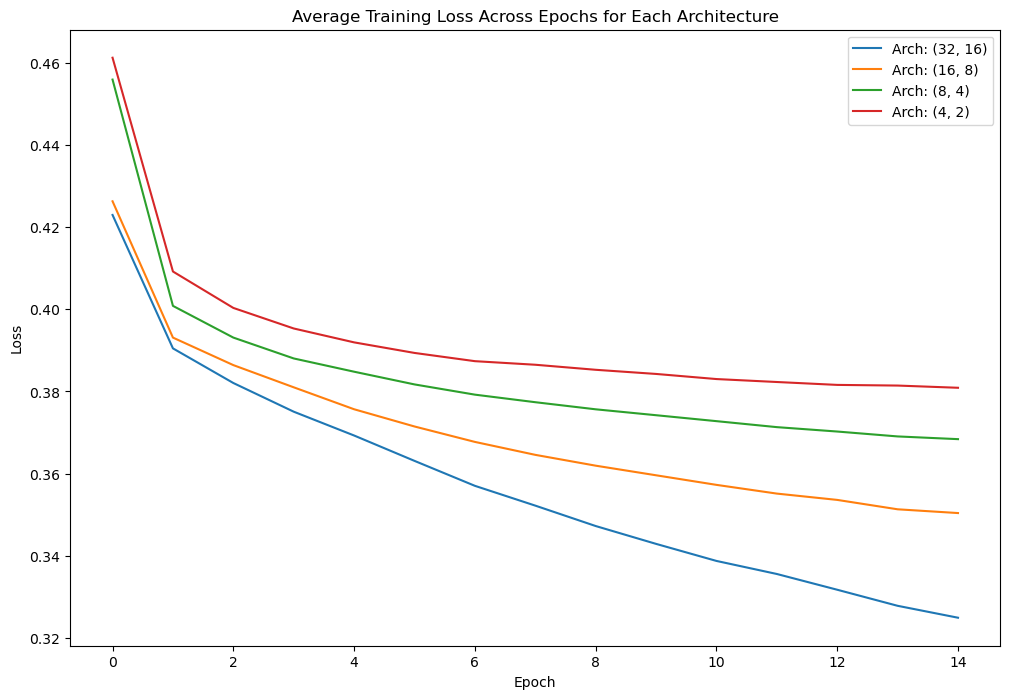

In [20]:
# graph loss history for each architecture (averaged across seeds)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for config in configs:
    # filter loss history for this architecture
    config_history = [h for h in loss_history if h["architecture"] == config]

    min_len = min(len(h["losses"]) for h in config_history)

    aligned_losses = [
        h["losses"][:min_len] for h in config_history
    ]
    
    # average losses across seeds
    avg_losses = np.mean(aligned_losses, axis=0)
    
    plt.plot(avg_losses, label=f"Arch: {config}")

plt.title("Average Training Loss Across Epochs for Each Architecture")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [21]:
results_flat = []
for r in results:
    flat_r = {
        "architecture": r["architecture"],
        "train_accuracy": r["train_accuracy"],
        "train_precision_rural": r["train_precision_class 0"],
        "train_precision_urban": r["train_precision_class 1"],
        "train_recall_rural": r["train_recall_class 0"],
        "train_recall_urban": r["train_recall_class 1"],
        "train_f1_rural": r["train_f1_class 0"],
        "train_f1_urban": r["train_f1_class 1"],
        "val_accuracy": r["val_accuracy"],
        "val_precision_rural": r["val_precision_class 0"],
        "val_precision_urban": r["val_precision_class 1"],
        "val_recall_rural": r["val_recall_class 0"],
        "val_recall_urban": r["val_recall_class 1"],
        "val_f1_rural": r["val_f1_class 0"],
        "val_f1_urban": r["val_f1_class 1"]
    }
    results_flat.append(flat_r)

results_df = pd.DataFrame(results_flat)
results_df.T

,0,1,2,3
architecture,"(32, 16)","(16, 8)","(8, 4)","(4, 2)"
train_accuracy,0.843614,0.831651,0.820842,0.806098
train_precision_rural,0.864348,0.860489,0.850301,0.8327
train_precision_urban,0.857337,0.824515,0.817165,0.824698
train_recall_rural,0.92059,0.898652,0.896382,0.906406
train_recall_urban,0.766639,0.76465,0.745302,0.705789
train_f1_rural,0.891495,0.879042,0.872678,0.867846
train_f1_urban,0.809148,0.793095,0.779412,0.760102
val_accuracy,0.800429,0.803182,0.802665,0.791752
val_precision_rural,0.835398,0.842138,0.839963,0.824272


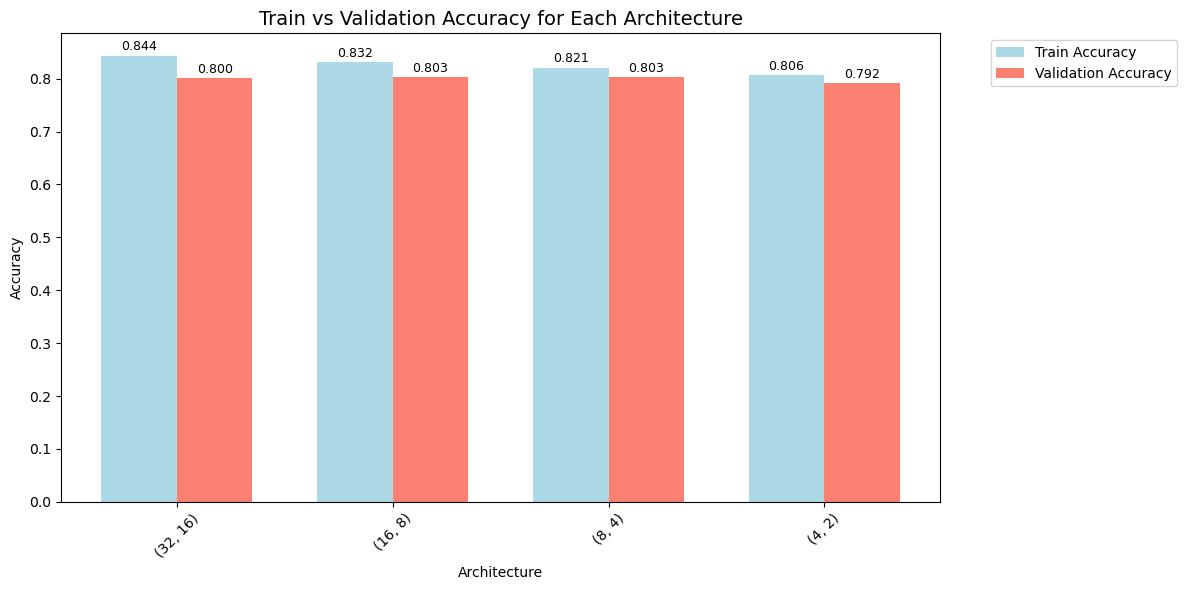

In [22]:
# see distribution of balanced accuracy scores in the training and validation set across different architectures
plt.figure(figsize=(12, 6))
x = np.arange(len(results_df["architecture"]))
bar_width = 0.35
plt.bar(x - bar_width/2, results_df["train_accuracy"], width=bar_width, label='Train Accuracy', color='lightblue')
plt.bar(x + bar_width/2, results_df["val_accuracy"], width=bar_width, label='Validation Accuracy', color='salmon')
plt.title("Train vs Validation Accuracy for Each Architecture", fontsize=14)
plt.xlabel("Architecture")
plt.ylabel("Accuracy")
# position legend outside the plot area to avoid overlap
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(x, results_df["architecture"], rotation=45)
plt.tight_layout()

# allow user to see the values on top of the bars
for i in range(len(results_df)):
    plt.text(i - bar_width/2, results_df["train_accuracy"].iloc[i] + 0.01, f"{results_df['train_accuracy'].iloc[i]:.3f}", ha='center', fontsize=9)
    plt.text(i + bar_width/2, results_df["val_accuracy"].iloc[i] + 0.01, f"{results_df['val_accuracy'].iloc[i]:.3f}", ha='center', fontsize=9)

The smaller architectures show lesser differences between training and validation balanced accuracies, indicating that they are able to better identify the correct label without overfitting. Moreover, both models exhibit similar validation balanced accuracies of around 0.80.

By the principle of Occam's Razor, it is therefore justified to select the neural network with the lesser neurons among them as this would lead to a similar result as the other, only with less memory consumption.

https://www.geeksforgeeks.org/machine-learning/occams-razor/

Thus, we proceed to fine tine the neural network with 2 hidden layers having a configuration of 4 and 2 neurons respectively.

### Comparison of different Hyperparameter Configurations

Performance of the model on different configurations of learning rates and batch sizes are compared.

In [ ]:
# increase epoch limit to observe convergence behavior of smaller architectures
epoch_limit = 100

learning_rates = [0.001, 0.005, 0.01]
batch_sizes = [32, 64, 128]

seeds = [0]  # using only one seed to save time.

# Only use one architecture
configs = [
    (4,2)
]

# list to store loss after each training epoch
loss_history = []

# to store results for each architecture
results = []

# Train for each learning rate and batch size combination
for lr in learning_rates:
    for bs in batch_sizes:

        # Train and evaluate the neural network for each architecture configuration
        criterion = nn.CrossEntropyLoss()
        data_loader = DataLoader(nn_X_train, nn_y_train, batch_size=bs)

        for hidden_layers in configs:

            run_metrics = []  # to store metrics for this architecture

            for seed in seeds:
                # Set seed for reproducibility
                os.environ['PYTHONHASHSEED'] = str(seed)
                random.seed(seed)
                np.random.seed(seed)
                torch.manual_seed(seed)
                torch.use_deterministic_algorithms(True)

                network = NeuralNetwork(
                    input_size=88,
                    list_hidden=hidden_layers,
                    activation='relu',
                    num_classes=2
                )

                print(f"\nTraining Neural Network with hidden layers: {hidden_layers}, seed: {seed}, learning rate: {lr}, batch size: {bs}")

                network.create_network()

                optimizer = optim.Adam(network.parameters(), lr=lr)

                training_losses = trainNetwork(network, data_loader, optimizer, criterion, max_epochs=epoch_limit)

                loss_history.append({
                    "architecture": hidden_layers,
                    "seed": seed,
                    "learning_rate": lr,
                    "batch_size": bs,
                    "losses": training_losses
                })

                # evaluate on both train and validation sets
                trainMetrics = evaluateNetwork(network, nn_X_train, nn_y_train)
                evalMetrics = evaluateNetwork(network, nn_X_val, nn_y_val)

                # store metrics of this run
                run_metrics.append({
                    "train": trainMetrics,
                    "val": evalMetrics
                })

            # compute averages across runs
            avg_train_metrics = {}
            for k, v in run_metrics[0]["train"].items():
                if isinstance(v, dict):  # nested dict
                    for subk in v:
                        avg_train_metrics[f"{k}_{subk}"] = np.mean([r["train"][k][subk] for r in run_metrics])
                else:  # simple float
                    avg_train_metrics[k] = np.mean([r["train"][k] for r in run_metrics])
            
            avg_val_metrics = {}
            for k, v in run_metrics[0]["val"].items():
                if isinstance(v, dict):
                    for subk in v:
                        avg_val_metrics[f"{k}_{subk}"] = np.mean([r["val"][k][subk] for r in run_metrics])
                else:
                    avg_val_metrics[k] = np.mean([r["val"][k] for r in run_metrics])

            # append averaged results for this architecture
            results.append({
                "architecture": hidden_layers,
                "learning_rate": lr,
                "batch_size": bs,
                **{"train_" + k: v for k, v in avg_train_metrics.items()},
                **{"val_" + k: v for k, v in avg_val_metrics.items()}
            })


Training Neural Network with hidden layers: (4, 2), seed: 0, learning rate: 0.001, batch size: 32
Epoch: 1 	Loss: 0.515936
Epoch: 2 	Loss: 0.431478
Epoch: 3 	Loss: 0.419477
Epoch: 4 	Loss: 0.412997
Epoch: 5 	Loss: 0.408795
Epoch: 6 	Loss: 0.405515
Epoch: 7 	Loss: 0.402922
Epoch: 8 	Loss: 0.400274
Epoch: 9 	Loss: 0.398537
Epoch: 10 	Loss: 0.397137
Epoch: 11 	Loss: 0.394740
Epoch: 12 	Loss: 0.393679
Epoch: 13 	Loss: 0.391763
Epoch: 14 	Loss: 0.390138
Epoch: 15 	Loss: 0.389224
Epoch: 16 	Loss: 0.388221
Epoch: 17 	Loss: 0.387410
Epoch: 18 	Loss: 0.386092
Epoch: 19 	Loss: 0.384728
Epoch: 20 	Loss: 0.384542
Epoch: 21 	Loss: 0.384029
Epoch: 22 	Loss: 0.383815
Epoch: 23 	Loss: 0.382796
Epoch: 24 	Loss: 0.381913
Epoch: 25 	Loss: 0.381813
Epoch: 26 	Loss: 0.380955
Epoch: 27 	Loss: 0.379962
Epoch: 28 	Loss: 0.380129
Epoch: 29 	Loss: 0.380423
Epoch: 30 	Loss: 0.379501
Epoch: 31 	Loss: 0.378809
Epoch: 32 	Loss: 0.378618
Epoch: 33 	Loss: 0.378326
Epoch: 34 	Loss: 0.378069
Epoch: 35 	Loss: 0.377463


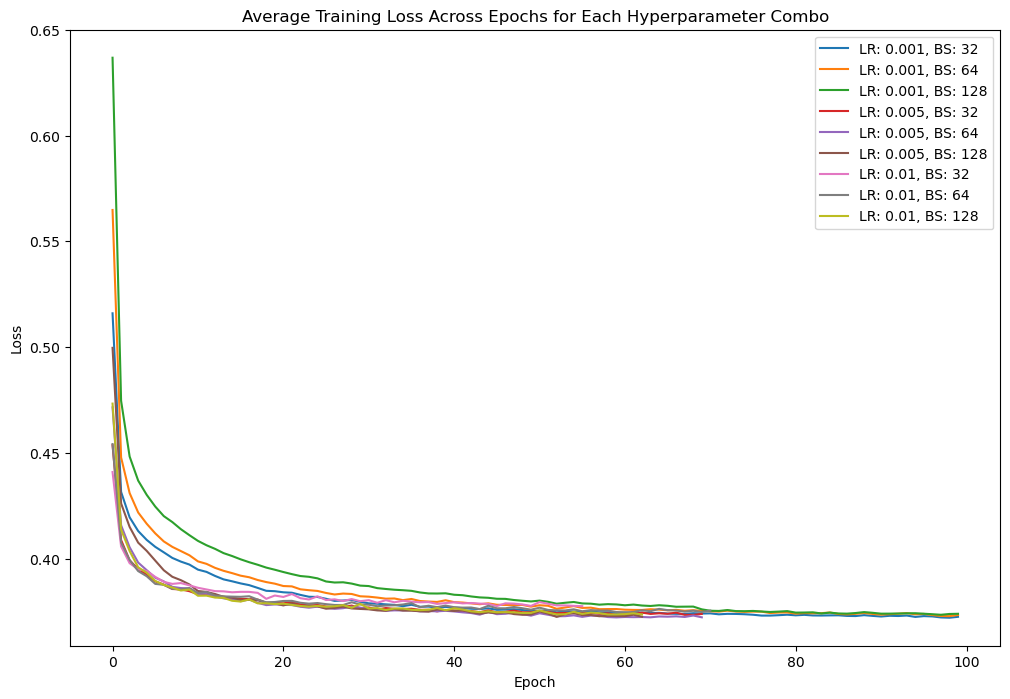

In [25]:
# graph loss history for each learning rate and batch size combination (averaged across seeds)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for lr in learning_rates:
    for bs in batch_sizes:
        # filter loss history for this learning rate and batch size
        config_history = [h for h in loss_history if h["architecture"] == (4, 2) and h["seed"] == 0 and h["learning_rate"] == lr and h["batch_size"] == bs]

        min_len = min(len(h["losses"]) for h in config_history)

        aligned_losses = [
            h["losses"][:min_len] for h in config_history
        ]
        
        # average losses across seeds
        avg_losses = np.mean(aligned_losses, axis=0)
        
        plt.plot(avg_losses, label=f"LR: {lr}, BS: {bs}")

plt.title("Average Training Loss Across Epochs for Each Hyperparameter Combo")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Among all the possible configurations, the model that used a learning rate of 0.01 and a batch size of 32 had the fastest convergence at epoch 56 with a final training loss of 0.3775.

The metrics for comparing the different configurations are displayed in table form. Balanced accuracies and f1 scores are visualized with a bar chart.

In [ ]:
# flatten results for viewing
results_flat = []
for r in results:
    flat_r = {
        "learning_rate": r["learning_rate"],
        "batch_size": r["batch_size"],
        "train_accuracy": r["train_accuracy"],
        "train_precision_rural": r["train_precision_class 0"],
        "train_precision_urban": r["train_precision_class 1"],
        "train_recall_rural": r["train_recall_class 0"],
        "train_recall_urban": r["train_recall_class 1"],
        "train_f1_rural": r["train_f1_class 0"],
        "train_f1_urban": r["train_f1_class 1"],
        "val_accuracy": r["val_accuracy"],
        "val_precision_rural": r["val_precision_class 0"],
        "val_precision_urban": r["val_precision_class 1"],
        "val_recall_rural": r["val_recall_class 0"],
        "val_recall_urban": r["val_recall_class 1"],
        "val_f1_rural": r["val_f1_class 0"],
        "val_f1_urban": r["val_f1_class 1"]
    }
    results_flat.append(flat_r)

results_df = pd.DataFrame(results_flat)
results_df.T

,0,1,2,3,4,5,6,7,8
learning_rate,0.001000,0.001000,0.001000,0.005000,0.005000,0.005000,0.010000,0.010000,0.010000
batch_size,32.000000,64.000000,128.000000,32.000000,64.000000,128.000000,32.000000,64.000000,128.000000
train_accuracy,0.810708,0.807944,0.809480,0.801930,0.804702,0.811325,0.817543,0.810046,0.813742
train_precision_rural,0.834007,0.832780,0.834921,0.821787,0.825276,0.836962,0.853386,0.832506,0.839838
train_precision_urban,0.837817,0.830705,0.828401,0.854505,0.850474,0.827969,0.794321,0.841501,0.826694
train_recall_rural,0.915255,0.910934,0.908803,0.928736,0.925452,0.907939,0.878557,0.918021,0.906268
train_recall_urban,0.706161,0.704953,0.710157,0.675123,0.683951,0.714711,0.756528,0.702072,0.721216
train_f1_rural,0.872744,0.870106,0.870297,0.871995,0.872498,0.871007,0.865789,0.873175,0.871789
train_f1_urban,0.766376,0.762680,0.764735,0.754296,0.758177,0.767182,0.774964,0.765490,0.770361
val_accuracy,0.792776,0.791970,0.796410,0.789453,0.788894,0.792607,0.799899,0.795962,0.796727


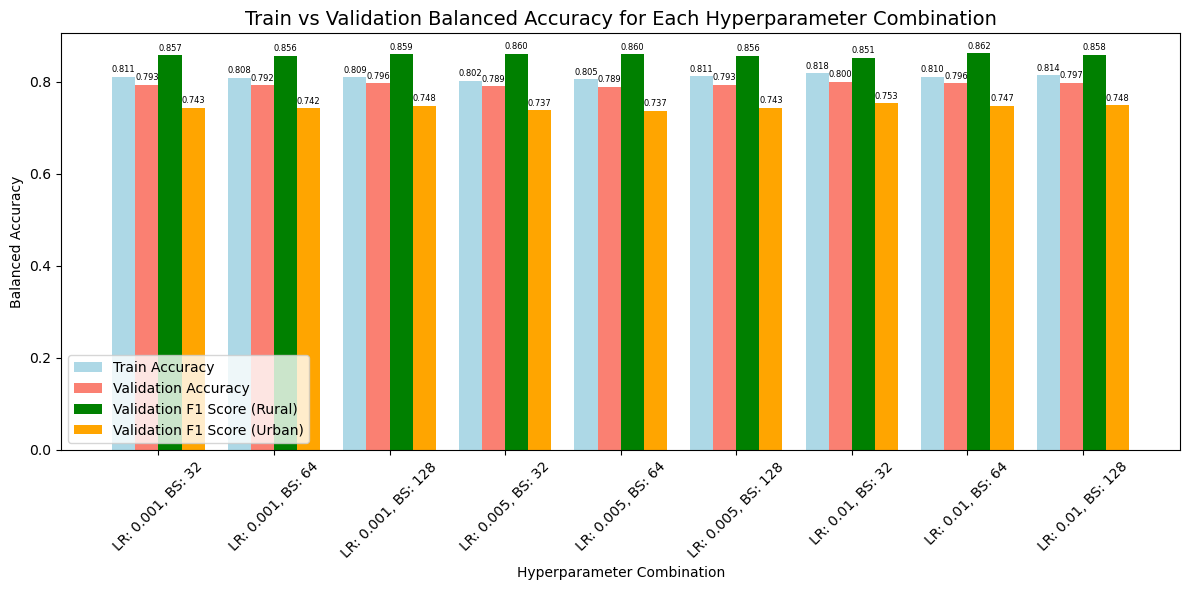

In [ ]:
# see comparison of balanced accuracy scores in the training and validation set and f1 scores across
# different combinations of learning rate and batch size using a bar chart
plt.figure(figsize=(12, 6))

# x-axis positions
x = np.arange(len(results_df))

bar_width = 0.2

# Plot bars
plt.bar(x - 1.5*bar_width, results_df["train_accuracy"], width=bar_width, label='Train Accuracy', color='lightblue')
plt.bar(x - 0.5*bar_width, results_df["val_accuracy"], width=bar_width, label='Validation Accuracy', color='salmon')
plt.bar(x + 0.5*bar_width, results_df["val_f1_rural"], width=bar_width, label='Validation F1 Score (Rural)', color='green')
plt.bar(x + 1.5*bar_width, results_df["val_f1_urban"], width=bar_width, label='Validation F1 Score (Urban)', color='orange')

# Titles and labels
plt.title("Train vs Validation Balanced Accuracy for Each Hyperparameter Combination", fontsize=14)
plt.xlabel("Hyperparameter Combination")
plt.ylabel(None)
plt.legend()

# X-axis labels
plt.xticks(
    x, 
    [f"LR: {lr}, BS: {bs}" for lr, bs in zip(results_df["learning_rate"], results_df["batch_size"])], 
    rotation=45
)

# Show values on top of bars
for i in range(len(results_df)):
    plt.text(i - 1.5*bar_width, results_df["train_accuracy"].iloc[i] + 0.01, f"{results_df['train_accuracy'].iloc[i]:.3f}", ha='center', fontsize=6)
    plt.text(i - 0.5*bar_width, results_df["val_accuracy"].iloc[i] + 0.01, f"{results_df['val_accuracy'].iloc[i]:.3f}", ha='center', fontsize=6)
    plt.text(i + 0.5*bar_width, results_df["val_f1_rural"].iloc[i] + 0.01, f"{results_df['val_f1_rural'].iloc[i]:.3f}", ha='center', fontsize=6)
    plt.text(i + 1.5*bar_width, results_df["val_f1_urban"].iloc[i] + 0.01, f"{results_df['val_f1_urban'].iloc[i]:.3f}", ha='center', fontsize=6)

plt.tight_layout()
plt.show()

All hyperparameter configurations tested using the architecture (4,2) resulted in similar training and validation balanced accuracies within 0.80 &plusmn; 0.01. The minimal difference between training and validation accuracies indicate that these models were also able to learn how to classify urban and rural households without overfitting on training data.

Although accuracies and f1 scores of each configuration is similar to one another, the model that trained with a learning rate 0.01 and batch size 32 will be used as it was able to converge within the least number of epochs.

# **[6]** Model Evaluation

Now that the final configurations have been identified, the final model will be trained, evaluated, and tested using these configurations and saved.

In [58]:
# increase epoch limit to observe convergence behavior of smaller architectures
epoch_limit = 100

# this time we only use one configuration
learning_rates = [0.01]
batch_sizes = [32]
seeds = [0]  # using seed for reproduciblity

# Only use one architecture
configs = [
    (4,2)
]

# list to store final weights of the trained model
weights = []

# list to store loss after each training epoch
loss_history = []

# to store results for each architecture
results = []

# Train for each learning rate and batch size combination
for lr in learning_rates:
    for bs in batch_sizes:

        # Train and evaluate the neural network for each architecture configuration
        criterion = nn.CrossEntropyLoss()
        data_loader = DataLoader(nn_X_train, nn_y_train, batch_size=bs)

        for hidden_layers in configs:

            run_metrics = []  # to store metrics for this architecture

            for seed in seeds:
                # Set seed for reproducibility
                os.environ['PYTHONHASHSEED'] = str(seed)
                random.seed(seed)
                np.random.seed(seed)
                torch.manual_seed(seed)
                torch.use_deterministic_algorithms(True)

                network = NeuralNetwork(
                    input_size=88,
                    list_hidden=hidden_layers,
                    activation='relu',
                    num_classes=2
                )

                print(f"\nTraining Neural Network with hidden layers: {hidden_layers}, seed: {seed}, learning rate: {lr}, batch size: {bs}")

                network.create_network()

                optimizer = optim.Adam(network.parameters(), lr=lr)

                training_losses = trainNetwork(network, data_loader, optimizer, criterion, max_epochs=epoch_limit)

                loss_history.append({
                    "architecture": hidden_layers,
                    "seed": seed,
                    "learning_rate": lr,
                    "batch_size": bs,
                    "losses": training_losses
                })

                # evaluate on train, validation, and test sets
                trainMetrics = evaluateNetwork(network, nn_X_train, nn_y_train)
                evalMetrics = evaluateNetwork(network, nn_X_val, nn_y_val)
                testMetrics = evaluateNetwork(network, nn_X_test, nn_y_test)

                # store metrics of this run
                run_metrics.append({
                    "train": trainMetrics,
                    "val": evalMetrics,
                    "test": testMetrics
                })

            # compute averages across runs
            avg_train_metrics = {}
            for k, v in run_metrics[0]["train"].items():
                if isinstance(v, dict):  # nested dict
                    for subk in v:
                        avg_train_metrics[f"{k}_{subk}"] = np.mean([r["train"][k][subk] for r in run_metrics])
                else:  # simple float
                    avg_train_metrics[k] = np.mean([r["train"][k] for r in run_metrics])
            
            avg_val_metrics = {}
            for k, v in run_metrics[0]["val"].items():
                if isinstance(v, dict):
                    for subk in v:
                        avg_val_metrics[f"{k}_{subk}"] = np.mean([r["val"][k][subk] for r in run_metrics])
                else:
                    avg_val_metrics[k] = np.mean([r["val"][k] for r in run_metrics])

            avg_test_metrics = {}
            for k, v in run_metrics[0]["test"].items():
                if isinstance(v, dict):
                    for subk in v:
                        avg_test_metrics[f"{k}_{subk}"] = np.mean([r["test"][k][subk] for r in run_metrics])
                else:
                    avg_test_metrics[k] = np.mean([r["test"][k] for r in run_metrics])

            # append averaged results for this architecture
            results.append({
                "architecture": hidden_layers,
                "learning_rate": lr,
                "batch_size": bs,
                **{"train_" + k: v for k, v in avg_train_metrics.items()},
                **{"val_" + k: v for k, v in avg_val_metrics.items()},
                **{"test_" + k: v for k, v in avg_test_metrics.items()}
            })
            
            # store final weights of the trained model
            weights.append({
                "architecture": hidden_layers,
                "seed": seed,
                "learning_rate": lr,
                "batch_size": bs,
                "final_weights": network.state_dict()
            })


Training Neural Network with hidden layers: (4, 2), seed: 0, learning rate: 0.01, batch size: 32
Epoch: 1 	Loss: 0.440873
Epoch: 2 	Loss: 0.405718
Epoch: 3 	Loss: 0.397784
Epoch: 4 	Loss: 0.394891
Epoch: 5 	Loss: 0.394095
Epoch: 6 	Loss: 0.391317
Epoch: 7 	Loss: 0.388961
Epoch: 8 	Loss: 0.387998
Epoch: 9 	Loss: 0.388383
Epoch: 10 	Loss: 0.387311
Epoch: 11 	Loss: 0.386159
Epoch: 12 	Loss: 0.385367
Epoch: 13 	Loss: 0.384580
Epoch: 14 	Loss: 0.384472
Epoch: 15 	Loss: 0.384031
Epoch: 16 	Loss: 0.384240
Epoch: 17 	Loss: 0.384226
Epoch: 18 	Loss: 0.383759
Epoch: 19 	Loss: 0.380937
Epoch: 20 	Loss: 0.382496
Epoch: 21 	Loss: 0.381826
Epoch: 22 	Loss: 0.383193
Epoch: 23 	Loss: 0.381227
Epoch: 24 	Loss: 0.380618
Epoch: 25 	Loss: 0.382107
Epoch: 26 	Loss: 0.380368
Epoch: 27 	Loss: 0.380700
Epoch: 28 	Loss: 0.379899
Epoch: 29 	Loss: 0.380820
Epoch: 30 	Loss: 0.379810
Epoch: 31 	Loss: 0.380307
Epoch: 32 	Loss: 0.379070
Epoch: 33 	Loss: 0.380301
Epoch: 34 	Loss: 0.379304
Epoch: 35 	Loss: 0.379996
E

In [59]:
# Save weights of final neural network model
joblib.dump(weights, 'final_neural_network_weights.pkl')

['final_neural_network_weights.pkl']

In [60]:
results

[{'architecture': (4, 2),
  'learning_rate': 0.01,
  'batch_size': 32,
  'train_accuracy': 0.8175428205956699,
  'train_precision_class 0': 0.8533855623950756,
  'train_precision_class 1': 0.7943213972094838,
  'train_recall_class 0': 0.8785574374927987,
  'train_recall_class 1': 0.756528203698541,
  'train_f1_class 0': 0.8657885772680821,
  'train_f1_class 1': 0.7749643027129938,
  'val_accuracy': 0.7998992809780936,
  'val_precision_class 0': 0.8416075650118203,
  'val_precision_class 1': 0.7674628210905814,
  'val_recall_class 0': 0.8612903225806452,
  'val_recall_class 1': 0.7385082393755421,
  'val_f1_class 0': 0.8513351933041052,
  'val_f1_class 1': 0.752707182320442,
  'test_accuracy': 0.804031675199806,
  'test_precision_class 0': 0.8445786295615647,
  'test_precision_class 1': 0.7731168245376635,
  'test_recall_class 0': 0.8647849462365591,
  'test_recall_class 1': 0.7432784041630529,
  'test_f1_class 0': 0.8545623588790012,
  'test_f1_class 1': 0.7579040459871768}]

In [102]:
# flatten results for viewing include training metrics
results_flat = []
for r in results:
    flat_r = {
        "learning_rate": r["learning_rate"],
        "batch_size": r["batch_size"],
        "train_accuracy": r["train_accuracy"],
        "train_precision_rural": r["train_precision_class 0"],
        "train_precision_urban": r["train_precision_class 1"],
        "train_recall_rural": r["train_recall_class 0"],
        "train_recall_urban": r["train_recall_class 1"],
        "train_f1_rural": r["train_f1_class 0"],
        "train_f1_urban": r["train_f1_class 1"],
        "val_accuracy": r["val_accuracy"],
        "val_precision_rural": r["val_precision_class 0"],
        "val_precision_urban": r["val_precision_class 1"],
        "val_recall_rural": r["val_recall_class 0"],
        "val_recall_urban": r["val_recall_class 1"],
        "val_f1_rural": r["val_f1_class 0"],
        "val_f1_urban": r["val_f1_class 1"],
        "test_accuracy": r["test_accuracy"],
        "test_precision_rural": r["test_precision_class 0"],
        "test_precision_urban": r["test_precision_class 1"],
        "test_recall_rural": r["test_recall_class 0"],
        "test_recall_urban": r["test_recall_class 1"],
        "test_f1_rural": r["test_f1_class 0"],
        "test_f1_urban": r["test_f1_class 1"],
    }
    results_flat.append(flat_r)

results_df = pd.DataFrame(results_flat)
results_df.T

,0
learning_rate,0.010000
batch_size,32.000000
train_accuracy,0.817543
train_precision_rural,0.853386
train_precision_urban,0.794321
train_recall_rural,0.878557
train_recall_urban,0.756528
train_f1_rural,0.865789
train_f1_urban,0.774964
val_accuracy,0.799899


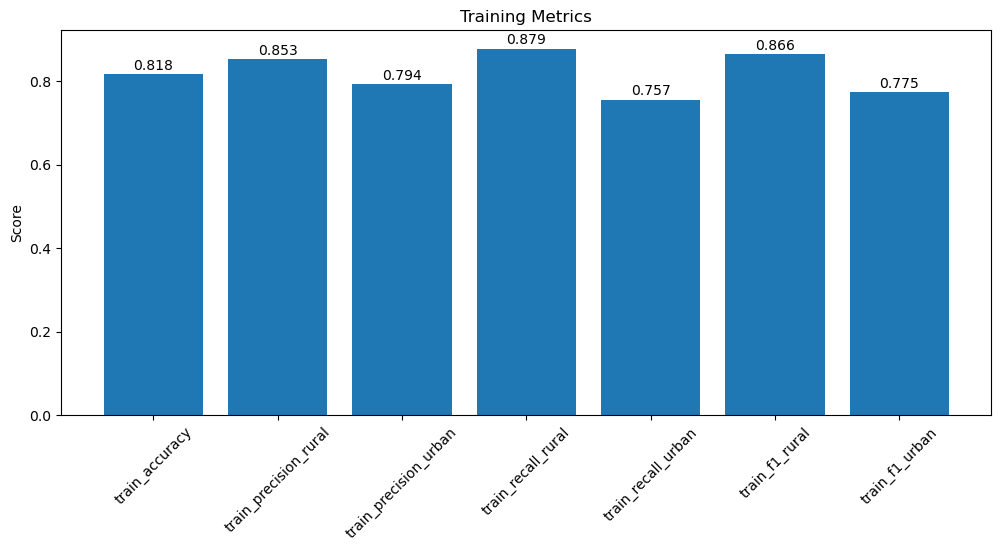

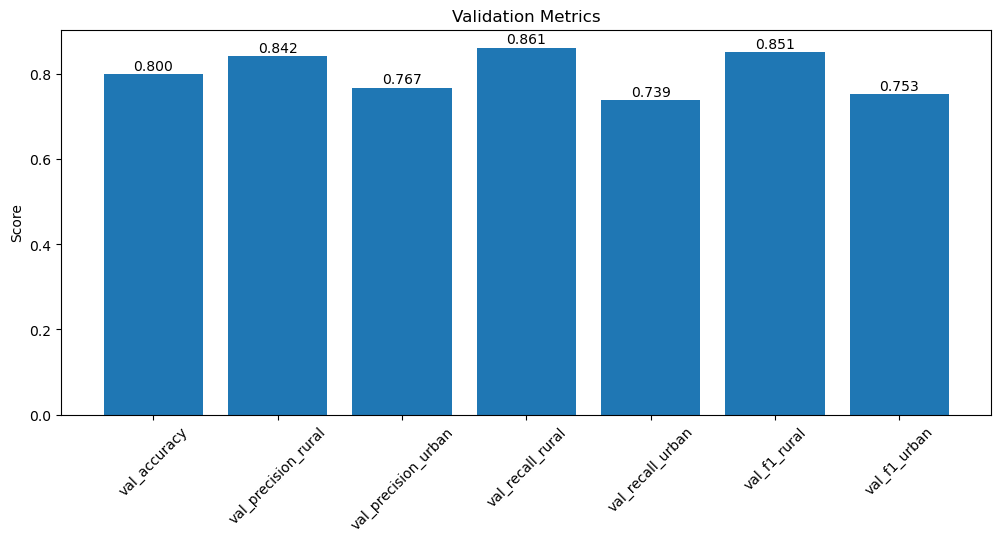

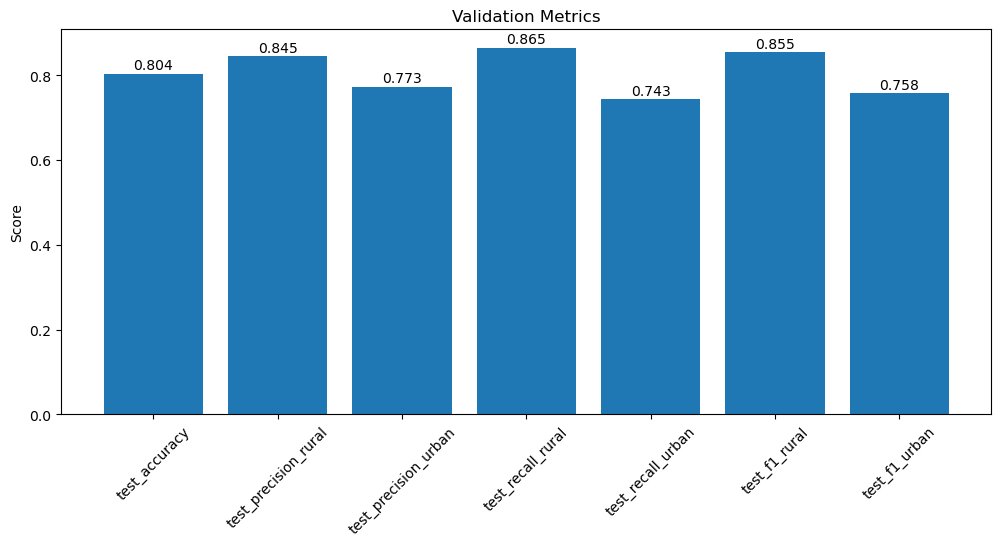

In [104]:
train_output = results_df[["train_accuracy","train_precision_rural","train_precision_urban","train_recall_rural","train_recall_urban","train_f1_rural","train_f1_urban"]]

row = train_output.iloc[0] 

metrics = row.index
values = row.values

x = np.arange(len(metrics))

plt.figure(figsize=(12, 5))
plt.bar(x, values)

plt.xticks(x, metrics, rotation=45)
plt.ylabel("Score")
plt.title("Training Metrics")

# Value labels
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

val_output = results_df[["val_accuracy","val_precision_rural","val_precision_urban","val_recall_rural","val_recall_urban","val_f1_rural","val_f1_urban"]]
val_output

row = val_output.iloc[0] 

metrics = row.index
values = row.values

x = np.arange(len(metrics))

plt.figure(figsize=(12, 5))
plt.bar(x, values)

plt.xticks(x, metrics, rotation=45)
plt.ylabel("Score")
plt.title("Validation Metrics")

# Value labels
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

test_output = results_df[["test_accuracy","test_precision_rural","test_precision_urban","test_recall_rural","test_recall_urban","test_f1_rural","test_f1_urban"]]

row = test_output.iloc[0] 

metrics = row.index
values = row.values

x = np.arange(len(metrics))

plt.figure(figsize=(12, 5))
plt.bar(x, values)

plt.xticks(x, metrics, rotation=45)
plt.ylabel("Score")
plt.title("Validation Metrics")

# Value labels
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

The final multi-layer perceptron was able to achieve a balanced accuracy within &plusmn; 0.80 across all set partitions. This indicates that it was able to successfully learn how to classify urban and rural households without overfitting on the training set.

<hr/>

# AI Declaration
Chavez, Allen Visagar
- sample text

Llanes, Andre Gabriel De Ocampo
- sample text

Rojo, Von Matthew De Guzman *(leader)*
- Uses Google-search that has AI features in synthesizing different sources relevant to questions I asked.
- Uses Google Gemini to ask ways on how to import CSV dataset and scaffolding ideas for EDA

Tan, Jeremy James Teves
- Uses ChatGPT to clarify proper flow for training loop
- Uses ChatGPT to assist with understanding errors that came up during debugging
- Uses ChatGPT to fix python syntax for neural network implementation and training